## kNN

In [1]:
import pandas as pd

In [9]:
# 데이터 import
train = pd.read_csv("../Data/basketball_train.csv")
test = pd.read_csv("../Data/basketball_test.csv")

In [10]:
print(test.shape)
print(train.shape)

(20, 5)
(80, 5)


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     object 
 1   Pos     80 non-null     object 
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.3+ KB


#### 최적의 k찾기와 교차검증(Cross Validation)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [20]:
# 최적의 k를 찾기위해 교차 검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] / 2
max_k_range = int(max_k_range)

In [21]:
k_list = [i for i in range(3, max_k_range, 2)]
k_list

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [23]:
train_data = train[['3P', 'BLK', 'TRB']]
train_target = train['Pos']

In [49]:
# 교차검증(10 fold)
cross_validation_scores = []
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        train_data,
        train_target,
        cv=10, #cross validation : 9개 = 학습용 / 1개 = 검증용
        scoring='accuracy'
    )
    avg = sum(scores) / len(scores)
    cross_validation_scores.append(avg)
    print(k, ":", scores)

3 : [0.875 0.875 0.875 0.875 0.875 0.875 0.75  1.    1.    0.75 ]
5 : [0.875 0.75  0.875 0.875 1.    1.    0.75  1.    1.    0.875]
7 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
9 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
11 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
13 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
15 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
17 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
19 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
21 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
23 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
25 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
27 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
29 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
31 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]

In [50]:
print(cross_validation_scores)

[np.float64(0.875), np.float64(0.9), np.float64(0.875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.875), np.float64(0.875), np.float64(0.8625), np.float64(0.85), np.float64(0.8375), np.float64(0.8375)]


In [51]:
import matplotlib.pyplot as plt

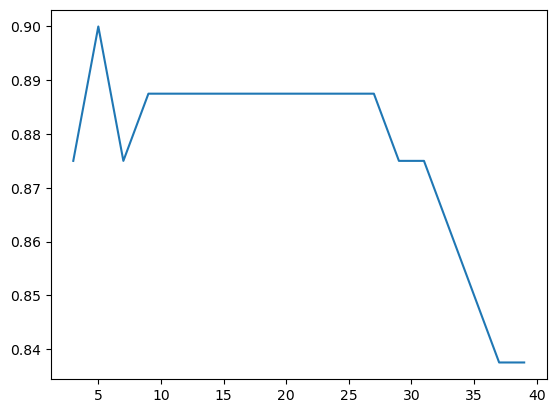

In [52]:
# k의 정확도 시각화
plt.plot(
    k_list,
    cross_validation_scores
)

plt.show()

In [53]:
# 가장 높은 예측율값 k 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

5

---
#### 2개의 특징으로 예측하기(3점슛, 블로킹)

In [54]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)

In [55]:
# Feature
train_data = train[['3P', 'BLK']]

In [56]:
# Target
train_target = train['Pos']

In [57]:
# 학습
knn.fit(train_data, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [58]:
test_data = test[['3P', 'BLK']]
test_target = test['Pos']

In [59]:
# 평가
print("Train :", knn.score(train_data, train_target))
print("Test :", knn.score(test_data, test_target))

Train : 0.9625
Test : 0.95


---
#### 3개의 특징으로 예측하기 (3점슛, 블로킹, 리바운드)

In [60]:
train_data = train[['3P', 'BLK', 'TRB']]
train_target = train['Pos']

In [61]:
# 학습
knn.fit(train_data, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
test_data = test[['3P', 'BLK', 'TRB']]
test_target = test['Pos']

In [63]:
# 평가
print("Train :", knn.score(train_data, train_target))
print("Test :", knn.score(test_data, test_target))

Train : 0.925
Test : 0.9


---
#### 학습한 AI Model 사용
주어진 선수의 점수
- 3P : 3.4
- BLK : 0.5
- TRB : 3.7
인 경우 포지션 추천